# Trabajo Practico 2

## Objetivo 
Seleccionar uno de los sets de datos que estan disponibles en el drive.

## Consigna 
Realizar un EDA basico del dataset seleccionado:
Estadistica descriptiva
Tipos de variables
Incluir al menos 3 graficos


## Dataset elegido: atp_tennis.csv


## 1. Importación de librerías y carga del dataset

In [31]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ruta = 'datasets/atp_tennis.csv'
df = pd.read_csv(ruta)

df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year == 2000].copy()

#Cambio los datos de -1 a nan
cols_centinela = ['Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Rank_1', 'Rank_2']
df[cols_centinela] = df[cols_centinela].replace(-1, np.nan)

print('Cantidad de registros de la muestra:', len(df))

df.head()

Cantidad de registros de la muestra: 2874


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105.0,58.0,NaN,NaN,NaN,NaN,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218.0,11.0,NaN,NaN,NaN,NaN,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56.0,5.0,NaN,NaN,NaN,NaN,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63.0,77.0,NaN,NaN,NaN,NaN,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155.0,15.0,NaN,NaN,NaN,NaN,4-6 4-6


## 2. Tipos de variables y estructura del dataset

En esta sección se observa la cantidad de filas y columnas, los nombres de las variables y el tipo de dato de cada columna.

In [ ]:
# Estructura del dataset
print("El dataset tiene la cantidad de filas y columnas: ", df.shape)

cuantitativas_discretas = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']
categoricas_nominales = ['Tournament', 'Court', 'Surface', 'Series', 'Player_1', 'Player_2', 'Winner']
temporales = ['Date']

print("CLASIFICACIÓN TEÓRICA DE VARIABLES")
print(" Cuantitativas Discretas:", cuantitativas_discretas)
print(" Categóricas Nominales:", categoricas_nominales)
print(" Temporales:", temporales)


El dataset tiene la cantidad de filas y columnas:  (2874, 17)
=== CLASIFICACIÓN TEÓRICA DE VARIABLES ===
• Cuantitativas Discretas: ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']
• Categóricas Nominales: ['Tournament', 'Court', 'Surface', 'Series', 'Player_1', 'Player_2', 'Winner']
• Temporales: ['Date']


## 3. Estadística descriptiva

Se calculan medidas como cantidad de datos, promedio, desvío estándar, valores mínimo y máximo para las variables numéricas.

In [33]:

print("\n=== ESTADÍSTICA DESCRIPTIVA (NUMÉRICAS) ===")
display(df[['Rank_1', 'Rank_2']].describe())

print("\n=== ESTADÍSTICA DESCRIPTIVA (CATEGÓRICAS) ===")
display(df[categoricas_nominales].describe())



=== ESTADÍSTICA DESCRIPTIVA (NUMÉRICAS) ===


,Rank_1,Rank_2
count,2868.000000,2871.000000
mean,79.310321,79.436782
std,99.581205,97.673819
min,1.000000,1.000000
25%,25.000000,26.000000
50%,55.000000,56.000000
75%,97.000000,97.000000
max,1312.000000,1351.000000



=== ESTADÍSTICA DESCRIPTIVA (CATEGÓRICAS) ===


,Tournament,Court,Surface,Series,Player_1,Player_2,Winner
count,2874,2874,2874,2874,2874,2874,2874
unique,69,2,4,5,287,286,233
top,Australian Open,Outdoor,Hard,International,Safin M.,Kafelnikov Y.,Safin M.
freq,124,2333,1496,1357,54,43,67


## 4. Relacion de las variables



In [34]:
print("=== MATRIZ DE CORRELACIÓN ENTRE RANKINGS ===")
display(df[['Rank_1', 'Rank_2']].corr(numeric_only=True))

print("\n=== TABLA DE CONTINGENCIA: SUPERFICIE VS CANCHA ===")
tabla_contingencia = pd.crosstab(df['Surface'], df['Court'], margins=True)
display(tabla_contingencia)


=== MATRIZ DE CORRELACIÓN ENTRE RANKINGS ===


,Rank_1,Rank_2
Rank_1,1.000000,0.055375
Rank_2,0.055375,1.000000



=== TABLA DE CONTINGENCIA: SUPERFICIE VS CANCHA ===


Court,Indoor,Outdoor,All
Surface,,,
Carpet,134,0,134
Clay,0,947,947
Grass,0,297,297
Hard,407,1089,1496
All,541,2333,2874


## 5. Gráficos



C:\Users\Usuario\AppData\Local\Temp\ipykernel_10488\440597397.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], data=df, x='Surface', y='Rank_1', palette='Set2')


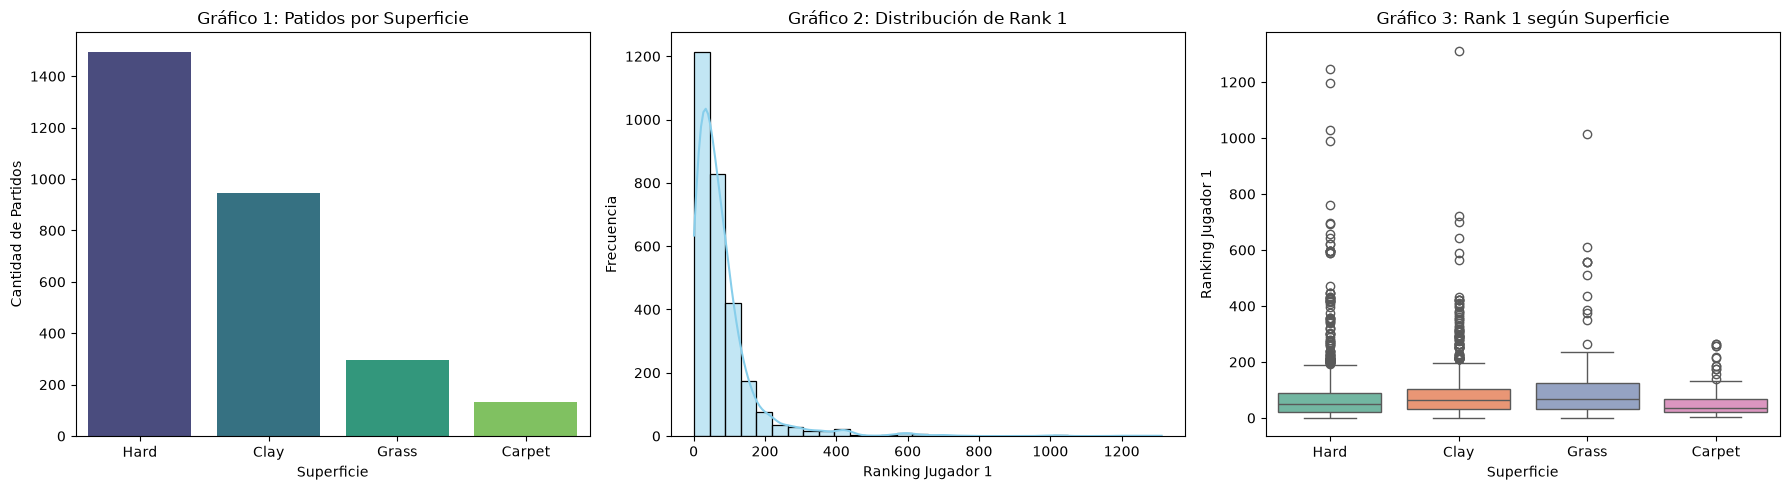

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.countplot(ax=axes[0], data=df, x='Surface', hue='Surface', legend=False, palette='viridis')
axes[0].set_title('Gráfico 1: Patidos por Superficie')
axes[0].set_xlabel('Superficie')
axes[0].set_ylabel('Cantidad de Partidos')


sns.histplot(ax=axes[1], data=df, x='Rank_1', bins=30, kde=True, color='skyblue')
axes[1].set_title('Gráfico 2: Distribución de Rank 1')
axes[1].set_xlabel('Ranking Jugador 1')
axes[1].set_ylabel('Frecuencia')


sns.boxplot(ax=axes[2], data=df, x='Surface', y='Rank_1', palette='Set2')
axes[2].set_title('Gráfico 3: Rank 1 según Superficie')
axes[2].set_xlabel('Superficie')
axes[2].set_ylabel('Ranking Jugador 1')

plt.tight_layout()
plt.show()

